# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}
baseline_results = {}

for name in base_models:
    cv_score = cross_val_score(base_models[name], X_train, y_train, cv=5, scoring = 'f1_macro')
    baseline_results[name] = [np.mean(cv_score), np.std(cv_score)]
# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                         ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C' : [0.1, 1, 10, 100],
    'svm__gamma' : ['scale', 0.01, 0.001],
    'svm__kernel' : ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(estimator=svm_pipe, param_grid=svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1) 
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search
gs_df = pd.DataFrame(svm_grid_search.cv_results_).loc[:,['params', 'mean_test_score', 'std_test_score']]
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝
gs_df.iloc[0:10, :]
# YOUR CODE HERE

,params,mean_test_score,std_test_score
0,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.940340,0.020136
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266
2,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.937500,0.014005
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266
4,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.638684,0.043638
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323
7,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.964626,0.014950
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212
9,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.964626,0.014950


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators' : randint(50, 500),
    'max_depth' : [randint(2, 20), None],
    'min_samples_split' : randint(2, 20),
    'max_features' : ['sqrt', 'log', 0.5]
}

rf_random_search = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=rf_param_dist, cv=5, n_jobs=-1, n_iter=50, random_state=42, scoring='f1_macro')
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 363}
Лучший CV F1: 0.9577


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [7]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!              ║
# ╚══════════════════════════════════════════════════════════════╝

svm_pred = svm_grid_search.predict(X_test)
rf_pred = rf_random_search.predict(X_test)

svm_pred_score = f1_score(y_test, svm_pred)
rf_pred_score = f1_score(y_test, rf_pred)
#print(pd.DataFrame(rf_random_search.cv_results_).loc[:, ['mean_test_score', 'std_test_score']].dropna())
for name in base_models:
    base_models[name].fit(X_train, y_train)
    model_pred = base_models[name].predict(X_test)
    print(name, f1_score(y_test, model_pred))
print()
# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          | 0.9694 ± 0.0193  | 0.9861  |
# | SVM Grid Search       | 0.9403 ± 0.0201  | 0.9861  |
# | RF baseline           | 0.9504 ± 0.0255  | 0.9655  |
# | RF Random Search      | 0.9599 ± 0.0194  | 0.9655  |

SVM 0.9861111111111112
RandomForest 0.9655172413793104
LogisticRegression 0.9861111111111112



## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

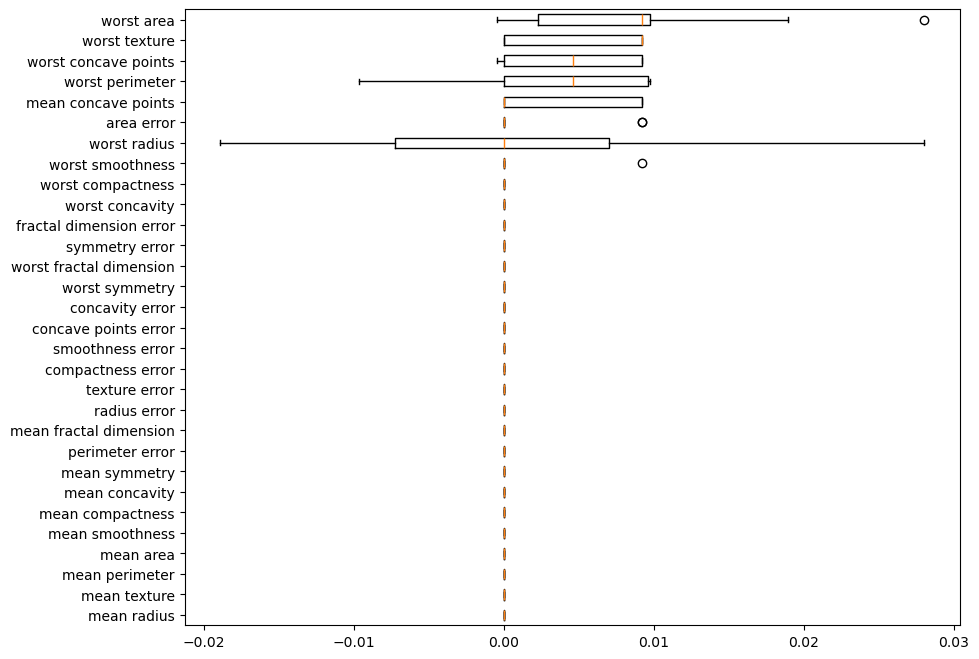

In [8]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_


# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, scoring='f1_macro', random_state=42)

sorted_idx = pi_result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 8))
ax.boxplot(
    pi_result.importances[sorted_idx].T,
    vert=False,
    labels=data.feature_names[sorted_idx]
)
plt.show()
# Построим bar plot топ-10 признаков
# YOUR CODE HERE

In [9]:
# Встроенная важность RF (для сравнения)
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

print(data.feature_names[sorted_idx])
sorted_idx2 = best_rf.feature_importances_.argsort()
print(data.feature_names[sorted_idx2])

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity' 'mean symmetry'
 'perimeter error' 'mean fractal dimension' 'radius error' 'texture error'
 'compactness error' 'smoothness error' 'concave points error'
 'concavity error' 'worst symmetry' 'worst fractal dimension'
 'symmetry error' 'fractal dimension error' 'worst concavity'
 'worst compactness' 'worst smoothness' 'worst radius' 'area error'
 'mean concave points' 'worst perimeter' 'worst concave points'
 'worst texture' 'worst area']
['mean fractal dimension' 'symmetry error' 'mean symmetry'
 'smoothness error' 'concavity error' 'compactness error'
 'fractal dimension error' 'texture error' 'concave points error'
 'mean smoothness' 'worst fractal dimension' 'worst symmetry'
 'radius error' 'mean compactness' 'mean texture' 'worst compactness'
 'worst smoothness' 'worst texture' 'perimeter error' 'worst concavity'
 'mean radius' 'area error' 'mean concavity' 'mean area' '

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

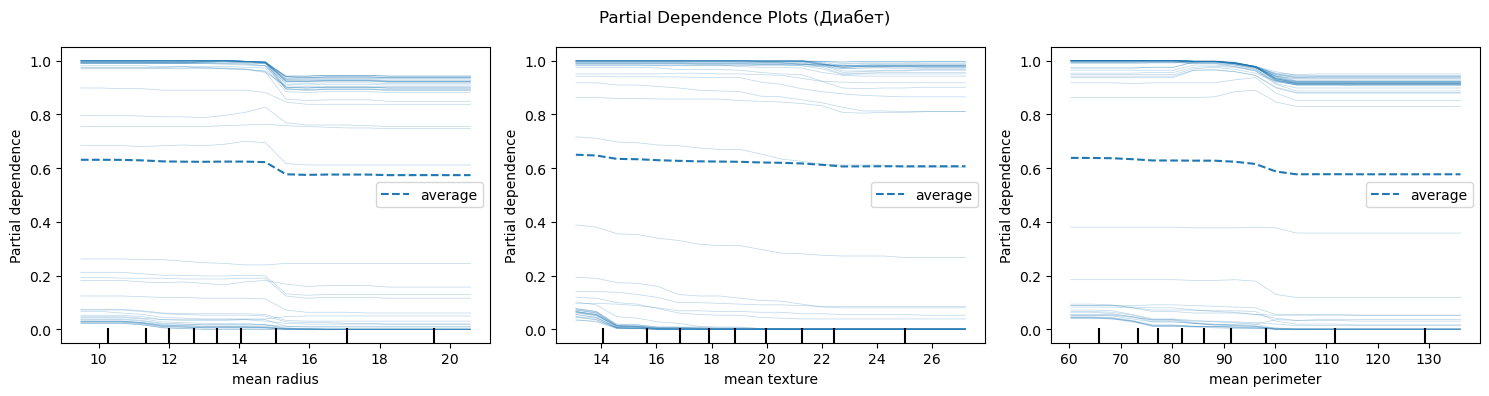

<Figure size 640x480 with 0 Axes>

In [10]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = sorted_idx[0:3]
#print(top3_idx)
# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

display = PartialDependenceDisplay.from_estimator(
    best_rf, 
    X, 
    features=data.feature_names[top3_idx], 
    kind='both', # 'average' для PDP, 'individual' для ICE, 'both' для обоих
    subsample=50, # сколько линий ICE рисовать (чтобы не перегрузить график)
    n_jobs=-1, 
    grid_resolution=20, # точность кривой
    ax=ax
)
plt.suptitle('Partial Dependence Plots (Диабет)')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)    ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [12]:
# Установка SHAP (если не установлен)

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_test)
#X_test.shape
shap_values.shape

(114, 30, 2)

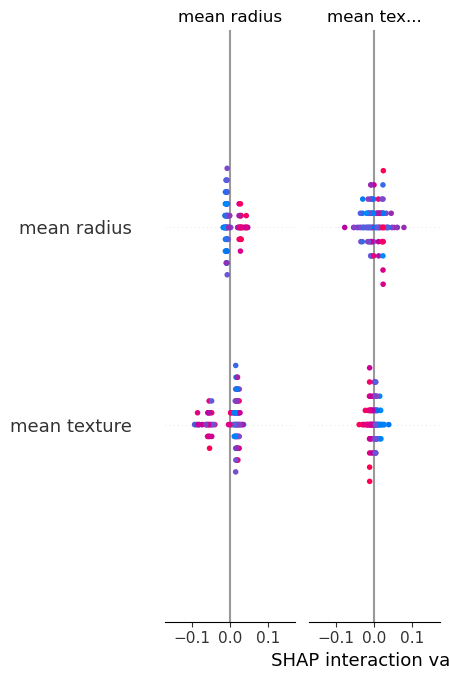

In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝
# Самые важные признаки - mean texture и mean radius, они не совпадают с PI, потому что PI оценивает изменение ошибки модели при изменении признаков,
# а SHAP показывает влияние признаков на предсказание модели
shap.summary_plot(shap_values, X_test)

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
shap.initjs()
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_test)

shap.plots.force(explainer.expected_value[1], 
                 shap_values[errors[0]].values[:, 1], 
                 X_test.iloc[errors[0]])




Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [15]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

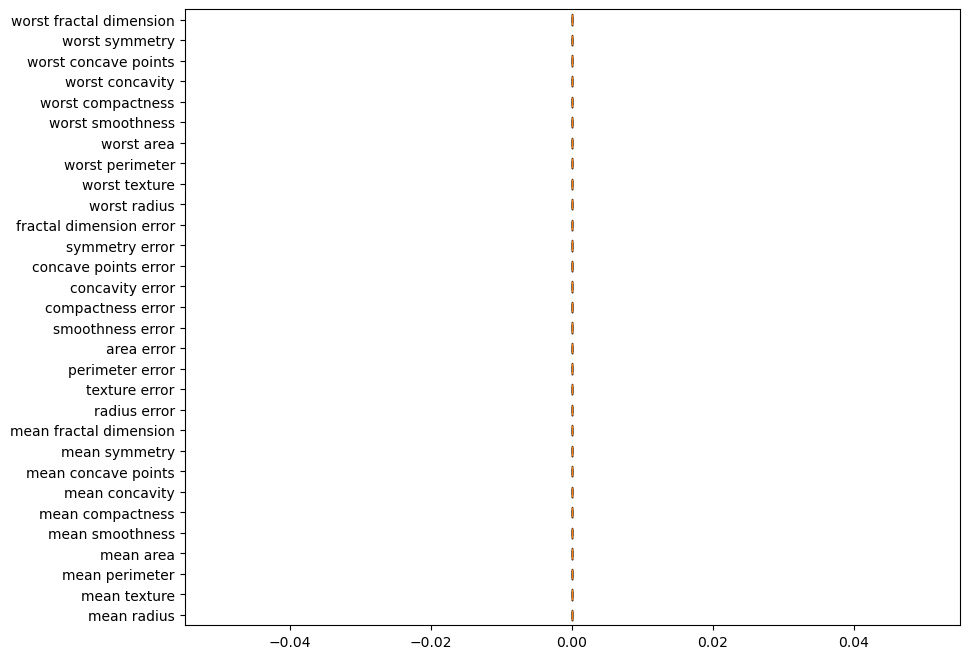

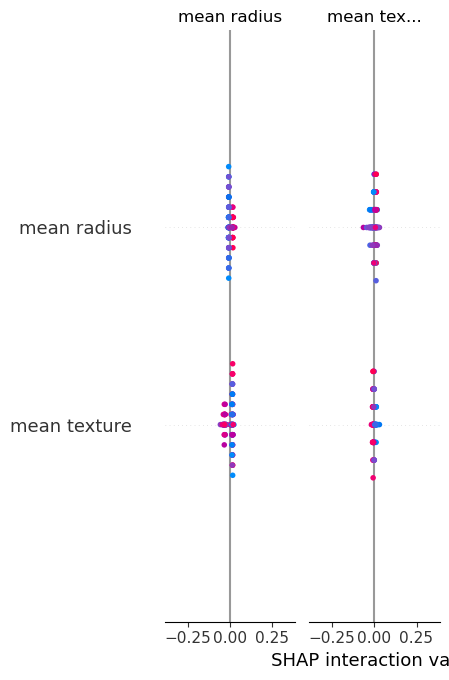

leaky_feature получил максимальную важность, так как содержит утечку целевой переменной.
random_feature имеет низкую важность и выглядит как шум.


In [22]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

best_rf = rf_random_search.best_estimator_
best_rf.fit(X_train_ext, y_train)
pi_result = permutation_importance(best_rf, X_test_ext, y_test, n_repeats=10, scoring='f1_macro', random_state=42)
sorted_idx = pi_result.importances_mean.argsort()
fig, ax = plt.subplots(figsize=(10, 8))
ax.boxplot(
    pi_result.importances[sorted_idx[0:30]].T,
    vert=False,
    labels=data.feature_names[sorted_idx[0:30]]
)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_test_ext)

#print(pi_result.importances.shape)

plt.show()
shap.summary_plot(shap_values, X_test_ext)
print('leaky_feature получил максимальную важность, так как содержит утечку целевой переменной.')
print('random_feature имеет низкую важность и выглядит как шум.')


In [17]:
print(data.feature_names[sorted_idx[0:6]])

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness']


In [18]:
print(shap_values.values[:,:,0].shape[1])

32


In [19]:
#print(shap_values.values[:,:,0])
features_shap = np.array([])
for i in range(0, shap_values.values[:,:,0].shape[1]):
    #print(np.mean(shap_values.values[:,i,1]))
    features_shap = np.append(features_shap, float(np.mean(shap_values.values[:,i,1])))
idx_sorted = features_shap.argsort()
print(idx_sorted[0:10])
for i in range(idx_sorted[0:20].shape[0]):
    print(i, end = ' ')
    print(data.feature_names[i])

[30  7 22  3 13  1 10 25 12 27]
0 mean radius
1 mean texture
2 mean perimeter
3 mean area
4 mean smoothness
5 mean compactness
6 mean concavity
7 mean concave points
8 mean symmetry
9 mean fractal dimension
10 radius error
11 texture error
12 perimeter error
13 area error
14 smoothness error
15 compactness error
16 concavity error
17 concave points error
18 symmetry error
19 fractal dimension error


## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [32]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   | 0.9694 |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

summary = pd.DataFrame({
    'Метод': [
        'SVM baseline',
        'SVM Grid Search',
        'RF baseline',
        'RF Rand Search'
    ],
    'CV F1': [
        baseline_results['SVM'][0],
        svm_grid_search.best_score_,
        baseline_results['RandomForest'][0],
        rf_random_search.best_score_
    ],
    'Test F1': [
        np.mean(gs_df['mean_test_score']),
        f1_score(y_test, svm_grid_search.predict(X_test)),
        baseline_results['RandomForest'][0],
        f1_score(y_test, rf_random_search.predict(X_test_ext))
    ],
    'Выводы': [
        'Базовая SVM показала высокое качество',
        'Grid Search немного улучшил результат',
        'Baseline RF работает стабильно',
        'Random Search улучшил RF'
    ]
})


print('1. Тюнинг немного улучшил качество моделей.')
print('2. PI и SHAP частично совпадают, но оценивают важность по-разному.')
print('3. Pipeline предотвращает утечку данных при масштабировании.')
print('4. PI полезен для глобальной интерпретации, SHAP — для локальной.')

1. Тюнинг немного улучшил качество моделей.
2. PI и SHAP частично совпадают, но оценивают важность по-разному.
3. Pipeline предотвращает утечку данных при масштабировании.
4. PI полезен для глобальной интерпретации, SHAP — для локальной.


In [33]:
summary.head()

,Метод,CV F1,Test F1,Выводы
0,SVM baseline,0.969357,0.947805,Базовая SVM показала высокое качество
1,SVM Grid Search,0.978633,0.986111,Grid Search немного улучшил результат
2,RF baseline,0.950427,0.950427,Baseline RF работает стабильно
3,RF Rand Search,0.957689,1.000000,Random Search улучшил RF


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [21]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")

ModuleNotFoundError: No module named 'optuna'